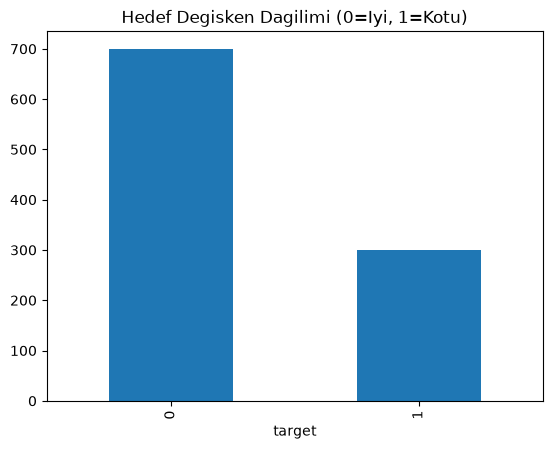

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/german_credit_clean.csv")
df["target"].value_counts().plot(kind="bar")
plt.title("Hedef Degisken Dagilimi (0=Iyi, 1=Kotu)")
plt.show()


In [ ]:
#eksik deger var mi ?
print(df.isnull().sum().sum()) #Eksik deger cikmadi

df.duplicated().sum() #Tekrarlanan satir yok

0


np.int64(0)

In [ ]:
df.describe() #Herhangibir aykırı deger tespit etmedim veriler olabilecek olasılıklarda.


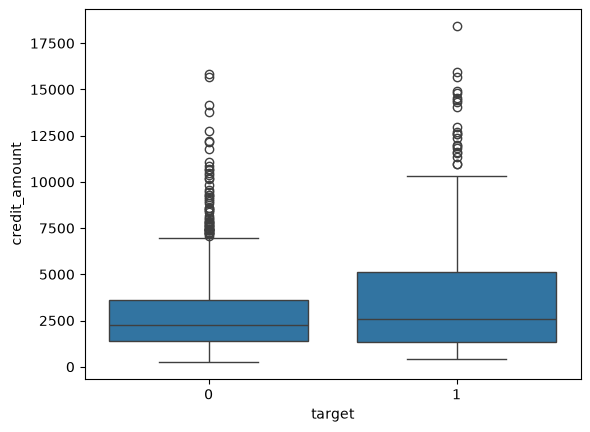

In [4]:
sns.boxplot(data = df , x="target",y="credit_amount")
plt.show()

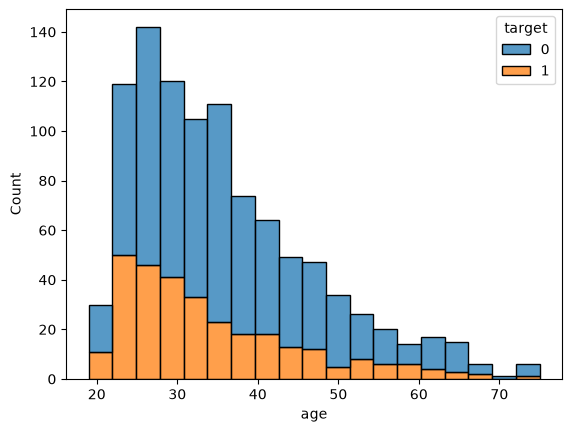

In [3]:
sns.histplot(data=df, x="age", hue="target", multiple="stack")
plt.show()

#grafikte anlamasi zor yaşın kötü kredi anlaması

In [5]:
df["age_group"] = pd.cut(df["age"], bins=[18, 25, 35, 45, 55, 100]) #yaşı gruplandırıyrouz 


In [6]:
df["age_group"].value_counts() #ayırdık kontrol ediyoruz 

age_group
(25, 35]     398
(35, 45]     226
(18, 25]     190
(45, 55]     115
(55, 100]     71
Name: count, dtype: int64

In [7]:
df.groupby("age_group")["target"].mean() #18 ve 25 yaş arasında kötü kredi yüzdesi %42 iken diğerleinden cok daha fazla


age_group
(18, 25]     0.421053
(25, 35]     0.296482
(35, 45]     0.243363
(45, 55]     0.243478
(55, 100]    0.267606
Name: target, dtype: float64

In [8]:
df.groupby("checking_account_status")["target"].mean()  #eksi bakiyeli hesabı olanlarda %49 kötü kredi, hesabı olmayanlarda sadece %12

checking_account_status
0-200 DM     0.390335
<0 DM        0.492701
>=200 DM     0.222222
hesap yok    0.116751
Name: target, dtype: float64

In [14]:

df["credit_history"].value_counts()  # sayi farkı cok fazla var ondan kredi yok hepsi odendi cok yuksek cikiyor
df.groupby("credit_history")["target"].mean()

credit_history
bu bankada odendi         0.571429
gecmiste gecikme          0.318182
kredi yok/hepsi odendi    0.625000
kritik hesap              0.170648
simdiye odendi            0.318868
Name: target, dtype: float64

In [16]:
print(df.groupby("purpose")["target"].mean())  #radyo/TV  %22, 280 kişi  düşük risk, en büyük ve en güvenilir grup
print(df["purpose"].value_counts())         #araba(yeni)  %38, 234 kişi  orta-yüksek risk, güvenilir

purpose
araba(eski)       0.165049
araba(yeni)       0.380342
diger             0.416667
egitim            0.440000
ev aleti          0.333333
is                0.350515
mobilya           0.320442
radyo/TV          0.221429
tamirat           0.363636
yeniden egitim    0.111111
Name: target, dtype: float64
purpose
radyo/TV          280
araba(yeni)       234
mobilya           181
araba(eski)       103
is                 97
egitim             50
tamirat            22
ev aleti           12
diger              12
yeniden egitim      9
Name: count, dtype: int64


In [20]:
df.groupby("purpose")["credit_amount"].mean()  #araba(eski)       5370.223301    #araba(yeni)       3063.025641
df.groupby("purpose")["age"].mean()  #yaşlarda aynı
df.groupby("purpose")["duration_months"].mean()   #eski araba 26 yeni 18                                          

purpose
araba(eski)       26.058252
araba(yeni)       18.504274
diger             32.333333
egitim            21.100000
ev aleti          16.833333
is                26.938144
mobilya           19.292818
radyo/TV          20.046429
tamirat           19.090909
yeniden egitim    11.777778
Name: duration_months, dtype: float64

In [21]:
#Neden yeni arabanın daha riskli oldugunu bulamadım buraya not alıyorum modeli eğitirken model kendisi bulacak.

In [23]:
#Modele basliyoruz simdi

#Veriyi X girdi (features)
#Y ise hedef (etiket)
X = df.drop(columns=["target"]) #(1000,21)
y = df["target"] #(1000,1)



In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.25,stratify=y)

In [27]:
print(X_train.shape, X_test.shape) #kontrol amacli dogru 250 veri testte

(750, 21) (250, 21)


In [29]:
print(y_train.value_counts(normalize=True))     #buda kontrol amacli stratify=y her iki gruba dogru oransal atmis mi diye kotnrol
print(y_test.value_counts(normalize=True))    

target
0    0.7
1    0.3
Name: proportion, dtype: float64
target
0    0.7
1    0.3
Name: proportion, dtype: float64


In [34]:
kategorik_sutunlar = X.select_dtypes(include=["object"]).columns.tolist()
sayisal_sutunlar = X.select_dtypes(exclude=["object"]).columns.tolist()
#print(kategorik_sutunlar)
#print(sayisal_sutunlar) #age_group ve age var age_group'u biz analiz icin olusturmustuk cikaracagiz gereksiz cunku
X = df.drop(columns=["target", "age_group"])
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.25,stratify=y) #tekrardan calistirmamiz lazım cunku X degisti
print(kategorik_sutunlar)
print(sayisal_sutunlar)


['checking_account_status', 'credit_history', 'purpose', 'savings_account', 'employment_since', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']
['duration_months', 'credit_amount', 'installment_rate_pct', 'residence_since', 'age', 'existing_credits', 'num_dependents']


C:\Users\egeme\AppData\Local\Temp\ipykernel_18588\1393348127.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  kategorik_sutunlar = X.select_dtypes(include=["object"]).columns.tolist()


In [45]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.ensemble import RandomForestClassifier


preprocessor = ColumnTransformer(transformers=[
    ("num",StandardScaler(),sayisal_sutunlar),  
    ("cat",OneHotEncoder(drop="first",handle_unknown="ignore"),kategorik_sutunlar)

])

In [52]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("model",RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, class_weight="balanced"))
])
pipeline.fit(X_train,y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['checking_account_status','duration_months','credit_history',..., 'num_dependents','telephone','foreign_worker']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By sp

In [ ]:
y_pred = pipeline.predict(X_test)
from sklearn.metrics import classification_report #karsilastiriyoz
print(classification_report(y_test,y_pred))






""" 
                 precision    recall  f1-score   support

           0       0.82      0.87      0.85       175
           1       0.65      0.55      0.59        75

    accuracy                           0.78       250
   macro avg       0.73      0.71      0.72       250
weighted avg       0.77      0.78      0.77       250   #Logistic Regression model sonuclarim bunlar bide randomForest kullanicam karsilastiricam.

"""




"""  

                  precision    recall  f1-score   support

           0       0.84      0.78      0.81       175
           1       0.56      0.67      0.61        75   Prescision degerim dustu ama recall degerim oldukca yukseldi ve bizim icin onemli olan buydu
                                                        Cunku recall degeri dusuk olursa burada 67 kisiye kötü dedi geriye kalan 33 kisi kötüydü iyi dedi
                                                        bu bizim icin kotu cunku krediyi geri ödemezler iste banka para kaybeder precision'da sadece
                                                        iyi olan musteriye kotu demis olur ve sadece kar kaybeder 1. iht.  daha kotu oldugu icin recalli
                                                        yuksek tutmaliyiz ondan random forest kullanacagim.
    accuracy                           0.74       250
   macro avg       0.70      0.72      0.71       250
weighted avg       0.76      0.74      0.75       250


"""

              precision    recall  f1-score   support

           0       0.84      0.78      0.81       175
           1       0.56      0.67      0.61        75

    accuracy                           0.74       250
   macro avg       0.70      0.72      0.71       250
weighted avg       0.76      0.74      0.75       250



"  \n\n                  precision    recall  f1-score   support\n\n           0       0.84      0.78      0.81       175\n           1       0.56      0.67      0.61        75   Prescision degerim dustu ama recall degerim oldukca yukseldi ve bizim icin onemli olan buydu\n                                                        Cunku recall degeri dusuk olursa burada 67 kisiye kötü dedi geriye kalan 33 kisi kötüydü iyi dedi\n                                                        bu bizim icin kotu cunku krediyi geri ödemezler iste banka para kaybeder precision'da sadece\n                                                        iyi olan musteriye kotu demis olur ve sadece kar kaybeder 1. iht.  daha kotu oldugu icin recalli\n                                                        yuksek tutmaliyiz ondan random forest kullanacagim.\n    accuracy                           0.74       250\n   macro avg       0.70      0.72      0.71       250\nweighted avg       0.76      0.74      0.75      

In [55]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(pipeline,X,y,cv = 5,scoring="recall")
print(scores)
print(f"ortalama = {scores.mean()}")
print(f"Std sapma = {scores.std()}") 




#Random Forest, Logistic Regression'dan 20 puan daha yüksek recall veriyor,

[0.73333333 0.61666667 0.68333333 0.68333333 0.71666667]
ortalama = 0.6866666666666668
Std sapma = 0.03999999999999998


In [57]:
kolon_isimleri = pipeline.named_steps["preprocessor"].get_feature_names_out()
print(len(kolon_isimleri))
print(kolon_isimleri[:10])

48
['num__duration_months' 'num__credit_amount' 'num__installment_rate_pct'
 'num__residence_since' 'num__age' 'num__existing_credits'
 'num__num_dependents' 'cat__checking_account_status_<0 DM'
 'cat__checking_account_status_>=200 DM'
 'cat__checking_account_status_hesap yok']


In [59]:
onem_skorlari = pipeline.named_steps["model"].feature_importances_

onem_df = pd.Series(onem_skorlari, index=kolon_isimleri).sort_values(ascending=False)
print(onem_df.head(15))

cat__checking_account_status_hesap yok    0.121694
num__credit_amount                        0.093714
num__duration_months                      0.088923
num__age                                  0.072446
cat__checking_account_status_<0 DM        0.046564
cat__credit_history_kritik hesap          0.037964
cat__savings_account_<100 DM              0.032790
num__installment_rate_pct                 0.032243
cat__other_installment_plans_A143         0.030282
cat__savings_account_bilinmiyor           0.026420
num__residence_since                      0.025367
cat__property_A124                        0.024124
cat__employment_since_<1 yil              0.018410
num__existing_credits                     0.018158
cat__personal_status_sex_A93              0.017006
dtype: float64


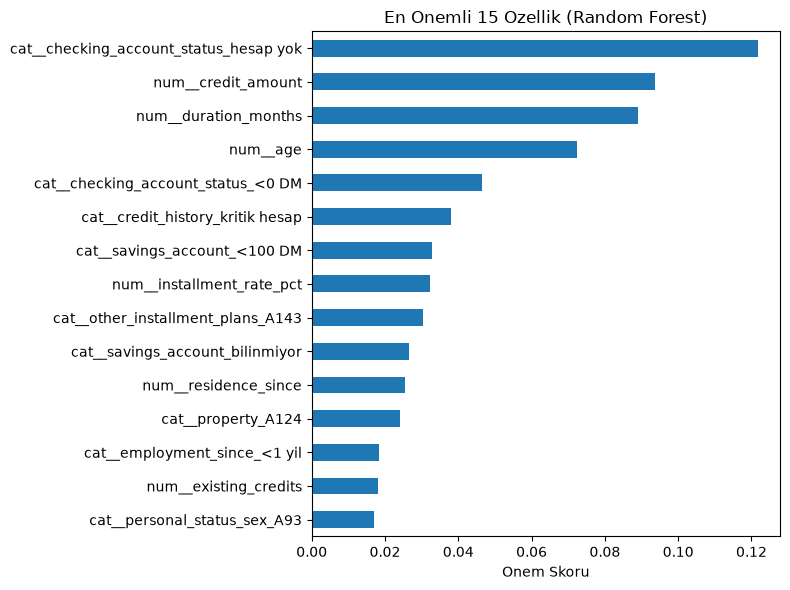

In [61]:
onem_df.head(15).sort_values().plot(kind="barh", figsize=(8,6))
plt.title("En Onemli 15 Ozellik (Random Forest)")
plt.xlabel("Onem Skoru")
plt.tight_layout()
plt.show()

In [69]:
y_proba = pipeline.predict_proba(X_test)[:, 1]  # [:,1] sadece kotu kredi olasiliklari
threshold = 0.50    
y_pred_yeni = (y_proba >= threshold).astype(int)

print(classification_report(y_test, y_pred_yeni))

              precision    recall  f1-score   support

           0       0.84      0.78      0.81       175
           1       0.56      0.67      0.61        75

    accuracy                           0.74       250
   macro avg       0.70      0.72      0.71       250
weighted avg       0.76      0.74      0.75       250



In [71]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [5, 8, 12],
}
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring="recall", n_jobs=-1)
grid_search.fit(X_train, y_train)



,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [5, 8, ...], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosit

In [73]:
print("En iyi parametreler:", grid_search.best_params_)
print("En iyi recall skoru:", grid_search.best_score_)

En iyi parametreler: {'model__max_depth': 5, 'model__n_estimators': 100}
En iyi recall skoru: 0.7022222222222222


In [74]:
y_pred_best = grid_search.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.86      0.71      0.78       175
           1       0.52      0.73      0.61        75

    accuracy                           0.72       250
   macro avg       0.69      0.72      0.70       250
weighted avg       0.76      0.72      0.73       250

